In [29]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import expit
from scipy.special import factorial

# Classification Problems: A Generative Model Approach

## Classification vs. Regression

In **regression**, the output variable $Y$ is continuous (a real number). In **classification**, the output variable $Y$ is qualitative—it takes a discrete value from a finite set of class labels.

**Example:**
- Regression: Predicting house price (continuous)
- Classification: Predicting image content as {dog, cat} (discrete)

---

## Formal Setup for Classification

Define:
- **$C$**: A discrete set containing $K$ class labels
- **Input**: A $p$-dimensional feature vector $x \in \mathbb{R}^p$
- **Output**: A class label $y \in C$
- **Goal**: Build a classifier $C(x)$ that maps inputs to labels

The classifier will make errors on some examples—we analyze and minimize these errors.

---

## The Generative Model Framework

We assume the data generation process follows **two steps**:

**Step 1: Sample the input**
$$x_i \sim f(X)$$

Sample an input vector from the marginal distribution $f(X)$ of the input variable.

**Step 2: Assign a label**
$$y_i \sim P_k(x_i), \quad k \in \{1, 2, \ldots, K\}$$

Given the sampled input $x_i$, assign a class label by sampling from the **conditional class probability** distribution.

### What is $P_k(x)$?

$P_k(x)$ is the **probability that the output is class $k$ given the input $x$**:

$$P_k(x) = P(Y = k \mid X = x)$$

This conditional probability tells us how likely each class is for a given input. It is the foundation of probabilistic classification.

---

## Intuition: The Biased Coin Flip

Think of $P_k(x)$ as defining a **biased coin with bias $P_k(x)$**. When we observe input $x_i$:

1. Look up $P_k(x_i)$ for each class $k$
2. These probabilities sum to 1 and define the bias of a multinomial "coin flip"
3. Flip this coin to sample the label $y_i$

**Key insight:** We are **not picking the most likely class**; we are **randomly sampling according to the probabilities**. This randomness reflects uncertainty in the data generation process.

### Numerical Example

Suppose $x$ is uniform on $[-2, 2]$ and $P_1(x) = \frac{1}{1 + e^{-4x}}$ (a sigmoid).

- At $x = 0.44$: $P_1(0.44) \approx 0.70$, so $P_0(0.44) \approx 0.30$
  - Flip a coin with 70% heads (class 1), 30% tails (class 0)

- At $x = -1.1$: $P_1(-1.1) \approx 0.10$, so $P_0(-1.1) \approx 0.90$
  - Flip a coin with 10% heads (class 1), 90% tails (class 0)
  - Result: mostly class 0, but occasionally class 1

---

## The Sigmoid Function: Visualizing Conditional Probability

The sigmoid function is a natural way to model $P_k(x)$:

$$\text{sigmoid}(z) = \frac{1}{1 + e^{-z}}$$

**Properties:**
- Sigmoid outputs a value between 0 and 1 (valid for a probability)
- Monotonically increasing
- Steepest slope at $z = 0$ (sigmoid $= 0.5$)
- Approaches 0 as $z \to -\infty$ and 1 as $z \to +\infty$

When we plot the sigmoid $P_1(x)$ against the scatter of sampled points, we see:
- **Where sigmoid is high** ($P_1(x) \approx 1$): most points are class 1, few are class 0
- **Where sigmoid is low** ($P_1(x) \approx 0$): most points are class 0, few are class 1
- **Where sigmoid is near 0.5**: classes are mixed with roughly equal frequency

---

## Key Connection: From Theory to Data

The **generative model provides a bridge**:

$$\text{Data generation} \quad \Rightarrow \quad \text{Conditional probability } P_k(x) \quad \Rightarrow \quad \text{Observed class patterns}$$

In practice, we observe the data and use it to **estimate** $P_k(x)$. Different classification algorithms (logistic regression, decision trees, neural networks) make different assumptions about the form of $P_k(x)$.

---

## Key Takeaways

- **Classification is probabilistic:** Labels are sampled from a distribution, not deterministically assigned.
- **$P_k(x)$ is fundamental:** It defines the probability of class $k$ given the input; understanding it is central to understanding classification.
- **Generative models explicitly model** $f(X)$ and $P_k(x)$, separating input distribution from class-conditional probabilities.
- **The sigmoid function is a natural choice** for modeling $P_k(x)$ in binary classification; it respects the probabilistic interpretation.
- **Observed class patterns emerge from the probabilities:** Where $P_1(x)$ is high, we expect to see mostly class 1; where it is low, we expect class 0.
- **The generative framework is foundational:** Logistic regression, Naive Bayes, and other classifiers all build on this probabilistic framework.

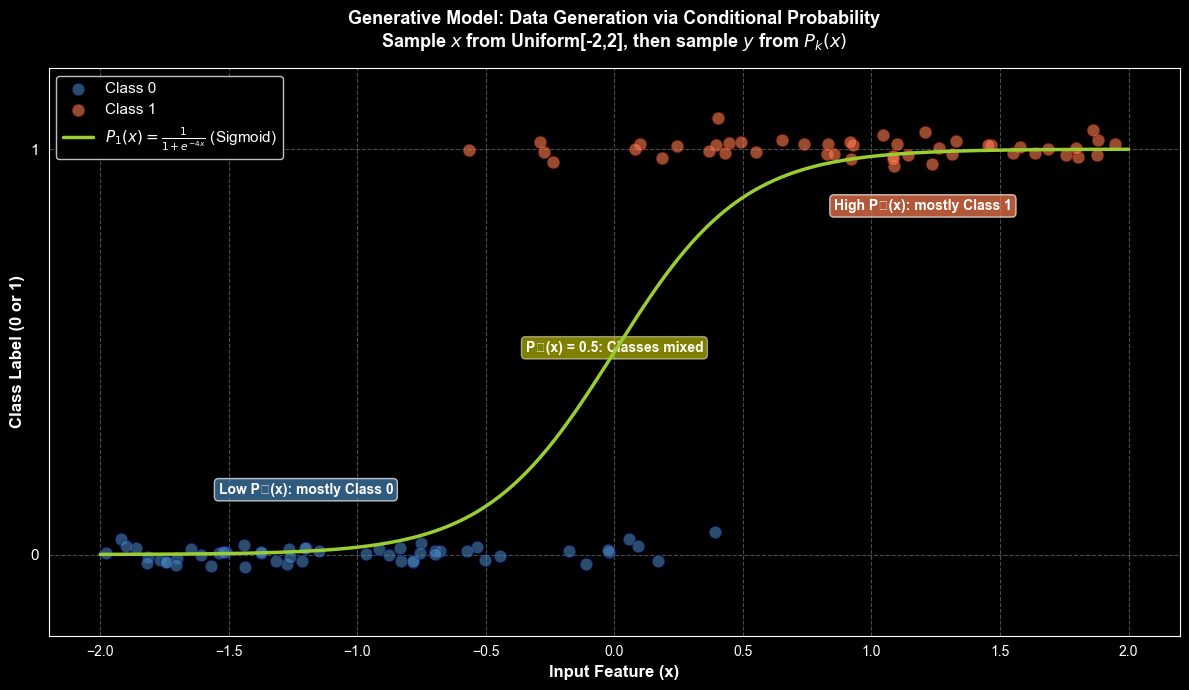

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit  # sigmoid function

# Set random seed for reproducibility
np.random.seed(42)

# Step 1: Sample inputs uniformly from [-2, 2]
n_samples = 100
X = np.random.uniform(-2, 2, n_samples)

# Step 2: Define conditional class probability using sigmoid
# P_1(x) = sigmoid(4x) = 1 / (1 + exp(-4x))
P_1 = expit(4 * X)  # This is the sigmoid
P_0 = 1 - P_1

# Step 3: Sample labels according to the conditional probability
# For each sample, flip a biased coin with bias P_1(x)
Y = np.array([np.random.binomial(1, p) for p in P_1])

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot data points colored by class
class_0_mask = Y == 0
class_1_mask = Y == 1

ax.scatter(X[class_0_mask], np.zeros(np.sum(class_0_mask)) + np.random.normal(0, 0.02, np.sum(class_0_mask)),
           alpha=0.6, s=80, color='steelblue', label='Class 0', edgecolors='darkblue', linewidth=0.5)
ax.scatter(X[class_1_mask], np.ones(np.sum(class_1_mask)) + np.random.normal(0, 0.02, np.sum(class_1_mask)),
           alpha=0.6, s=80, color='coral', label='Class 1', edgecolors='darkred', linewidth=0.5)

# Plot the sigmoid function P_1(x) as a reference curve
x_smooth = np.linspace(-2, 2, 300)
P_1_smooth = expit(4 * x_smooth)

ax.plot(x_smooth, P_1_smooth, 'k-', linewidth=2.5, label=r'$P_1(x) = \frac{1}{1 + e^{-4x}}$ (Sigmoid)', zorder=5,color='yellowgreen')

# Formatting
ax.set_xlabel('Input Feature (x)', fontsize=12, fontweight='bold')
ax.set_ylabel('Class Label (0 or 1)', fontsize=12, fontweight='bold')
ax.set_title('Generative Model: Data Generation via Conditional Probability\n' +
             r'Sample $x$ from Uniform[-2,2], then sample $y$ from $P_k(x)$',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(-0.2, 1.2)
ax.set_yticks([0, 1])
ax.set_yticklabels(['0', '1'], fontsize=11)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

# Add annotation boxes to highlight key insights
textstr1 = 'High P₁(x): mostly Class 1'
ax.text(1.2, 0.85, textstr1, fontsize=10, bbox=dict(boxstyle='round', facecolor='coral', alpha=0.7),
        ha='center', fontweight='bold')

textstr2 = 'Low P₁(x): mostly Class 0'
ax.text(-1.2, 0.15, textstr2, fontsize=10, bbox=dict(boxstyle='round', facecolor='steelblue', alpha=0.7),
        ha='center', fontweight='bold')

textstr3 = r'P₁(x) = 0.5: Classes mixed'
ax.text(0, 0.5, textstr3, fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5),
        ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

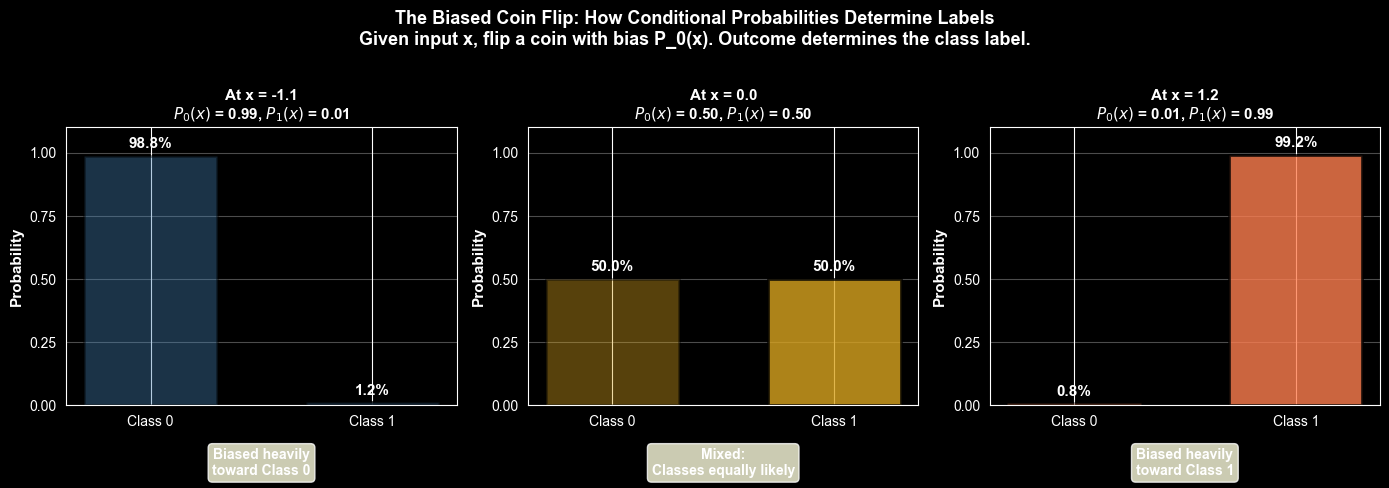

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

# Create figure with subplots showing specific examples
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Three example points: x = -1.1, x = 0, x = 1.2
example_x_values = [-1.1, 0.0, 1.2]
colors = ['steelblue', 'goldenrod', 'coral']

for idx, (x_val, color) in enumerate(zip(example_x_values, colors)):
    ax = axes[idx]

    # Calculate conditional probabilities at this x
    P_1_val = expit(4 * x_val)
    P_0_val = 1 - P_1_val

    # Create a visual representation of the biased coin flip
    classes = ['Class 0', 'Class 1']
    probs = [P_0_val, P_1_val]
    alphas = [0.4, 0.8]  # Different opacity for each bar

    # Bar plot showing the probabilities
    for i, (cls, prob, alpha) in enumerate(zip(classes, probs, alphas)):
        ax.bar(i, prob, color=color, alpha=alpha, edgecolor='black', linewidth=2, width=0.6)
        # Add probability values on bars
        ax.text(i, prob + 0.02, f'{prob:.1%}', ha='center', va='bottom',
                fontsize=11, fontweight='bold')

    # Formatting
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Probability', fontsize=11, fontweight='bold')
    ax.set_title(f'At x = {x_val}\n' + r'$P_0(x)$' + f' = {P_0_val:.2f}, ' + r'$P_1(x)$' + f' = {P_1_val:.2f}',
                 fontsize=11, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Class 0', 'Class 1'], fontsize=10)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.grid(True, alpha=0.3, axis='y')

    # Add interpretation text
    if P_1_val > 0.7:
        interpretation = 'Biased heavily\ntoward Class 1'
    elif P_1_val < 0.3:
        interpretation = 'Biased heavily\ntoward Class 0'
    else:
        interpretation = 'Mixed:\nClasses equally likely'

    ax.text(0.5, -0.25, interpretation, fontsize=10, ha='center', transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontweight='bold')

fig.suptitle('The Biased Coin Flip: How Conditional Probabilities Determine Labels\n' +
             'Given input x, flip a coin with bias P_0(x). Outcome determines the class label.',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# The Bayes Optimal Classifier

## What Is It?

The **Bayes Optimal Classifier (BOC)** is a theoretical classifier that assigns the label to an input $x$ that has the **highest conditional class probability**.

**Definition:**
$$C(x) = \arg\max_k P(Y = k \mid X = x)$$

**Why it matters:** This classifier minimizes the classification error rate—it's the best we can possibly do if we know the true class probabilities.

---

## Binary Classification Example

For binary classification ($k \in \{0, 1\}$), the BOC rule is simple:
- Assign class 1 if $P(Y = 1 \mid X = x) \geq P(Y = 0 \mid X = x)$
- Otherwise assign class 0

Since probabilities sum to 1: $P(Y = 0 \mid X = x) = 1 - P(Y = 1 \mid X = x)$

This creates a **decision boundary** where the two probabilities are equal—a point (or threshold) where the classifier switches from predicting 0 to predicting 1.

In the lecture example, this boundary was at $x = 0$: classify as 1 if $x \geq 0$, else 0.

---

## The Practical Problem: We Don't Know P(Y = k | X = x)

In reality, nature generates data according to an **unknown generative model**. We see the data, but not the true conditional class probabilities.

We face the same challenge as in regression: we're given data but don't know the parameters that generated it.

---

## Solution 1: Local Averaging

**Idea:** Estimate the conditional class probabilities using nearby points.

**How it works:**
1. Choose a window (neighborhood) around the input $x$ we want to classify
2. Count how many points of each class fall in that window
3. Estimate the conditional probability:

$$
P(Y = k \mid X = x)
\approx
\frac{\text{# of class } k \text{ points in the window}}
{\text{Total # of points in the window}}
$$

This gives us an estimate $\hat{P}_1(x)$, which we can use to build an approximate classifier $\hat{C}(x)$ using the same decision rule as the BOC.

**Key insight:** The decision boundary moves slightly but stays close to where the true probabilities cross over.

---

## The Curse of Dimensionality Strikes Again

Local Averaging works in low dimensions, but **fails in high dimensions** because:
- In high dimensions, all points are far apart
- A "local" neighborhood becomes empty—no nearby points to count
- We can't get reliable probability estimates

This is the same problem that made local averaging unreliable for regression in high dimensions.

**Solution:** Use a structured model (like logistic regression or other parametric approaches) instead of local averaging.

---

## Summary: The Decision Chain

$$\text{True } P(Y = k \mid X = x) \rightarrow \text{Bayes Optimal Classifier} \rightarrow \text{Minimizes error}$$

But in practice:
$$\text{Data} \rightarrow \text{Local Averaging} \rightarrow \text{Estimate } \hat{P}(Y = k \mid X = x) \rightarrow \text{Approximate BOC}$$

With the caveat: Local Averaging only works in low dimensions.

---

## Key Takeaways

- The **Bayes Optimal Classifier assigns each input to the class with the highest conditional probability**; it minimizes classification error.
- **Decision boundaries occur where P(Y=1|X) = P(Y=0|X)**; the classifier switches predictions at this threshold.
- We don't know the true conditional probabilities, so we must estimate them from data.
- **Local Averaging** estimates these probabilities by counting class labels in a neighborhood around each point.
- Local Averaging fails in high dimensions due to the curse of dimensionality (no nearby points to count).

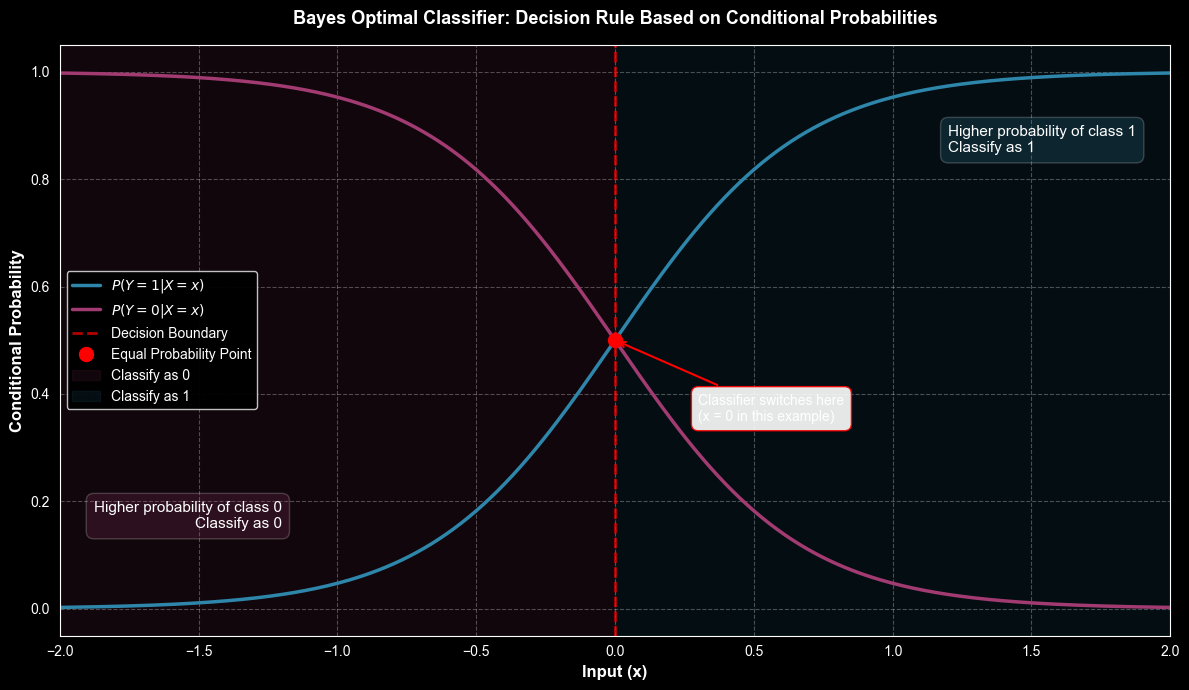

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Generate the true conditional probability (sigmoid-like curve from the lecture)
x = np.linspace(-2, 2, 300)
P_1 = 1 / (1 + np.exp(-3 * x))  # Simulates the gray curve from lecture
P_0 = 1 - P_1

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot true conditional probabilities
ax.plot(x, P_1, label=r'$P(Y=1|X=x)$', linewidth=2.5, color='#2E86AB', linestyle='-')
ax.plot(x, P_0, label=r'$P(Y=0|X=x)$', linewidth=2.5, color='#A23B72', linestyle='-')

# Highlight decision boundary
decision_boundary = 0  # Where P_1(x) = P_0(x) = 0.5
ax.axvline(decision_boundary, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Decision Boundary')
ax.plot(decision_boundary, 0.5, 'ro', markersize=10, label='Equal Probability Point')

# Shade regions
ax.axvspan(-2, decision_boundary, alpha=0.1, color='#A23B72', label='Classify as 0')
ax.axvspan(decision_boundary, 2, alpha=0.1, color='#2E86AB', label='Classify as 1')

# Annotations with key insights
ax.annotate('Higher probability of class 1\nClassify as 1',
            xy=(1.2, 0.85), fontsize=11, ha='left',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#2E86AB', alpha=0.2))
ax.annotate('Higher probability of class 0\nClassify as 0',
            xy=(-1.2, 0.15), fontsize=11, ha='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#A23B72', alpha=0.2))
ax.annotate('Classifier switches here\n(x = 0 in this example)',
            xy=(0, 0.5), xytext=(0.3, 0.35), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='red', alpha=0.9))

# Formatting
ax.set_xlabel('Input (x)', fontsize=12, fontweight='bold')
ax.set_ylabel('Conditional Probability', fontsize=12, fontweight='bold')
ax.set_title('Bayes Optimal Classifier: Decision Rule Based on Conditional Probabilities',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='center left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(-2, 2)

plt.tight_layout()
plt.show()

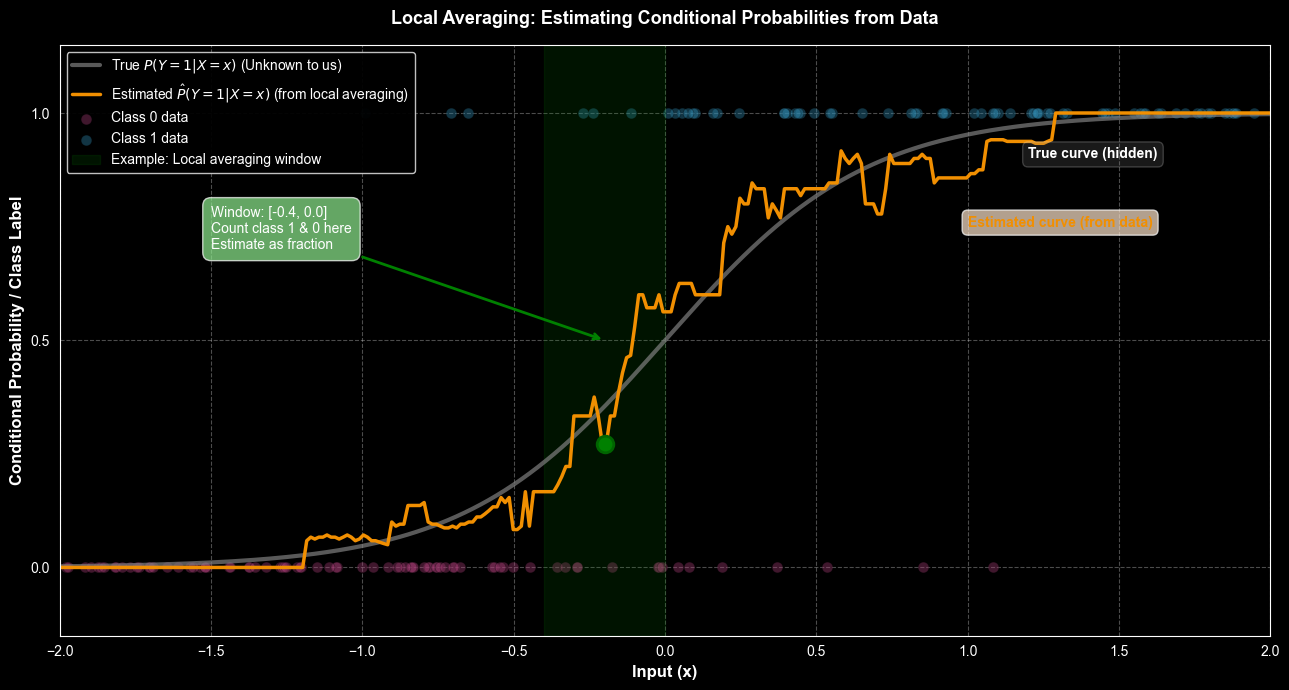

In [45]:
# Generate synthetic data with known class probabilities
np.random.seed(42)
n_points = 150
x = np.random.uniform(-2, 2, n_points)
true_prob_1 = 1 / (1 + np.exp(-3 * x))
y = (np.random.uniform(0, 1, n_points) < true_prob_1).astype(int)

# True conditional probability (what nature knows, but we don't)
x_true = np.linspace(-2, 2, 300)
P_1_true = 1 / (1 + np.exp(-3 * x_true))

# Local averaging estimation
def estimate_local_prob(x_eval, x_data, y_data, window_width):
    """Estimate P(Y=1|X=x_eval) using local averaging"""
    P_1_hat = []
    for xi in x_eval:
        in_window = np.abs(x_data - xi) <= window_width / 2
        if np.sum(in_window) > 0:
            P_1_hat.append(np.mean(y_data[in_window]))
        else:
            P_1_hat.append(np.nan)
    return np.array(P_1_hat)

P_1_hat = estimate_local_prob(x_true, x, y, window_width=0.4)

# Create figure
fig, ax = plt.subplots(figsize=(13, 7))

# Plot true conditional probability
ax.plot(x_true, P_1_true, 'k-', linewidth=3, label=r'True $P(Y=1|X=x)$ (Unknown to us)', alpha=0.7, color='gray')

# Plot estimated conditional probability
ax.plot(x_true, P_1_hat, linewidth=2.5, color='#F18F01', label=r'Estimated $\hat{P}(Y=1|X=x)$ (from local averaging)', linestyle='-')

# Plot data points
class_0_x = x[y == 0]
class_1_x = x[y == 1]
ax.scatter(class_0_x, np.zeros_like(class_0_x), alpha=0.4, s=60, color='#A23B72', label='Class 0 data', edgecolors='black', linewidth=0.5)
ax.scatter(class_1_x, np.ones_like(class_1_x), alpha=0.4, s=60, color='#2E86AB', label='Class 1 data', edgecolors='black', linewidth=0.5)

# Highlight a specific example window
x_example = -0.2
window_half_width = 0.2
ax.axvspan(x_example - window_half_width, x_example + window_half_width,
           alpha=0.15, color='green', label='Example: Local averaging window')
ax.plot(x_example, P_1_hat[np.argmin(np.abs(x_true - x_example))], 'go', markersize=12, markeredgewidth=2, markeredgecolor='darkgreen')

# Annotation explaining the window
ax.annotate(f'Window: [{x_example - window_half_width:.1f}, {x_example + window_half_width:.1f}]\nCount class 1 & 0 here\nEstimate as fraction',
            xy=(x_example, 0.5), xytext=(-1.5, 0.7), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            bbox=dict(boxstyle='round,pad=0.6', facecolor='lightgreen', alpha=0.7))

ax.annotate('True curve (hidden)', xy=(1.2, 0.9), fontsize=10, color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='gray', alpha=0.2))
ax.annotate('Estimated curve (from data)', xy=(1.0, 0.75), fontsize=10, color='#F18F01', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFE5CC', alpha=0.7))

# Formatting
ax.set_xlabel('Input (x)', fontsize=12, fontweight='bold')
ax.set_ylabel('Conditional Probability / Class Label', fontsize=12, fontweight='bold')
ax.set_title('Local Averaging: Estimating Conditional Probabilities from Data',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(-0.15, 1.15)
ax.set_xlim(-2, 2)
ax.set_yticks([0, 0.5, 1])

plt.tight_layout()
plt.show()

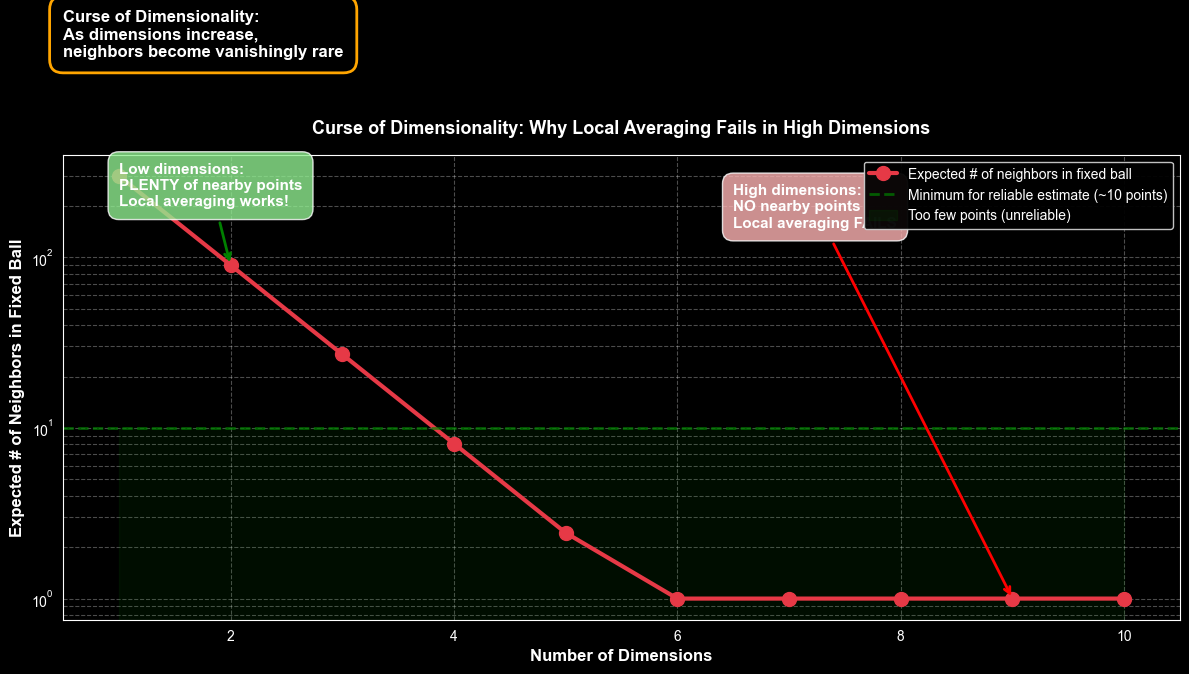

In [51]:
# Simulate: how many neighbors fall in a fixed-size ball as dimension increases?
dimensions = np.arange(1, 11)
n_total_points = 1000
radius = 0.3

# In d dimensions, a ball of radius r has volume ~ r^d
# So expected # of points in ball ≈ n_total_points * (volume of ball / volume of data space)
# For unit hypercube, volume ≈ r^d for small r

expected_neighbors = []
for d in dimensions:
    ball_volume = np.pi ** (d / 2) / factorial(d // 2) * (radius ** d) if d % 2 == 0 else \
                  (2 ** ((d + 1) / 2) * factorial((d - 1) // 2) / factorial(d)) * (radius ** d)
    # Simplified: for unit hypercube
    n_neighbors = n_total_points * (radius ** d)
    expected_neighbors.append(max(n_neighbors, 1))

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the decay
ax.plot(dimensions, expected_neighbors, 'o-', linewidth=3, markersize=10,
        color='#E63946', label='Expected # of neighbors in fixed ball')
ax.axhline(y=10, color='green', linestyle='--', linewidth=2, alpha=0.7,
           label='Minimum for reliable estimate (~10 points)')
ax.fill_between(dimensions, 0, 10, alpha=0.1, color='green', label='Too few points (unreliable)')

# Annotations
ax.annotate('Low dimensions:\nPLENTY of nearby points\nLocal averaging works!',
            xy=(2, expected_neighbors[1]), xytext=(1, 200), fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            bbox=dict(boxstyle='round,pad=0.7', facecolor='lightgreen', alpha=0.8))

ax.annotate('High dimensions:\nNO nearby points\nLocal averaging FAILS',
            xy=(9, expected_neighbors[8]), xytext=(6.5, 150), fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            bbox=dict(boxstyle='round,pad=0.7', facecolor='#FFB4B4', alpha=0.8))

ax.text(0.5, 1500, 'Curse of Dimensionality:\nAs dimensions increase,\nneighbors become vanishingly rare',
        fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='black', edgecolor='orange', linewidth=2))

# Formatting
ax.set_xlabel('Number of Dimensions', fontsize=12, fontweight='bold')
ax.set_ylabel('Expected # of Neighbors in Fixed Ball', fontsize=12, fontweight='bold')
ax.set_title('Curse of Dimensionality: Why Local Averaging Fails in High Dimensions',
             fontsize=13, fontweight='bold', pad=15)
ax.set_yscale('log')
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3, which='both', linestyle='--')
ax.set_xlim(0.5, 10.5)

plt.tight_layout()
plt.show()